Exploratory Data Analysis on cardiographic.csv

1.Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

 2. Load Dataset

In [27]:
df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\Cardiotocographic.csv")
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


3. Data Cleaning & Preparation

Check Basic Info

In [28]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


(2126, 14)

Check Missing Values

In [29]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

Handle Missing Values

In [30]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Check Data Types

In [31]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

Detect Outliers (Boxplot)

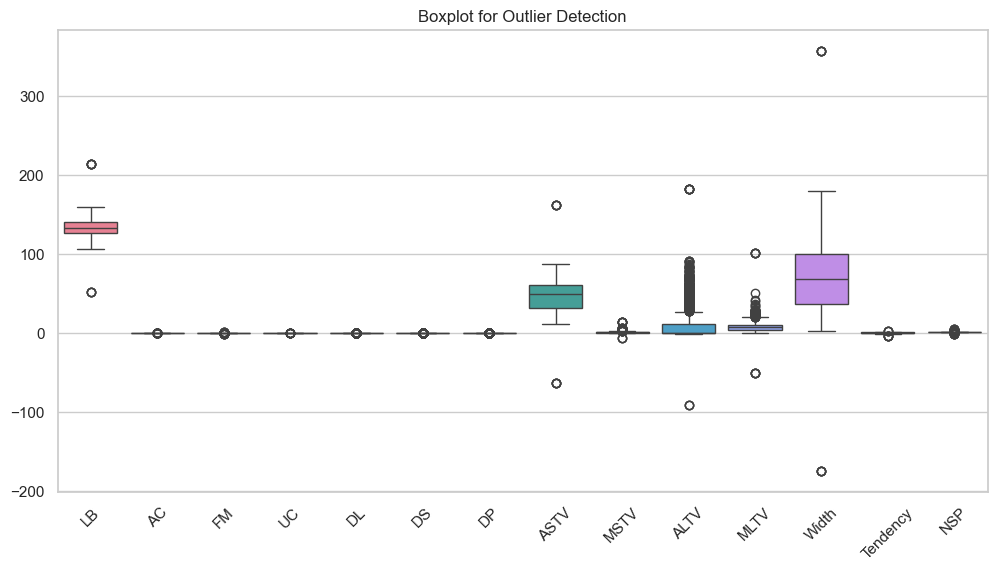

In [32]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

Remove Outliers (IQR Method)

In [33]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]


4. Statistical Summary

In [34]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,883.000000,883.000000,883.000000,883.000000,883.000000,883.0,883.0,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.0
mean,131.842621,0.004071,0.000603,0.004952,0.001545,0.0,0.0,42.401260,1.271275,3.170071,8.613856,67.795732,0.338671,1.0
std,9.461012,0.003726,0.001337,0.002718,0.002218,0.0,0.0,15.079872,0.538496,6.036208,4.487502,32.607863,0.588830,0.0
min,106.000000,-0.000122,-0.002467,-0.000101,-0.000124,0.0,0.0,15.000000,0.300000,-1.043619,-0.136053,12.000000,-1.006614,1.0
25%,125.000000,0.000000,0.000000,0.003098,0.000000,0.0,0.0,29.000000,0.900000,0.000000,5.600000,40.000000,0.000000,1.0
50%,133.000000,0.003350,0.000000,0.005051,0.000000,0.0,0.0,41.000000,1.200000,0.000000,8.500000,61.000000,0.000000,1.0
75%,138.000000,0.006719,0.000336,0.006927,0.003084,0.0,0.0,56.000000,1.600000,4.000000,11.400000,92.408185,1.000000,1.0
max,160.000000,0.013861,0.006272,0.012072,0.008197,0.0,0.0,79.000000,3.200000,27.000000,20.000000,176.310998,1.023635,1.0


Median

In [35]:
df.median(numeric_only=True)

LB          133.000000
AC            0.003350
FM            0.000000
UC            0.005051
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         41.000000
MSTV          1.200000
ALTV          0.000000
MLTV          8.500000
Width        61.000000
Tendency      0.000000
NSP           1.000000
dtype: float64

In [36]:
IQR

LB          14.000000
AC           0.005606
FM           0.002567
UC           0.004685
DL           0.003289
DS           0.000000
DP           0.000000
ASTV        29.000000
MSTV         1.000000
ALTV        11.000000
MLTV         6.200000
Width       63.000000
Tendency     1.000000
NSP          0.000000
dtype: float64

In [37]:
IQR = df.quantile(0.75) - df.quantile(0.25)
IQR

LB          13.000000
AC           0.006719
FM           0.000336
UC           0.003830
DL           0.003084
DS           0.000000
DP           0.000000
ASTV        27.000000
MSTV         0.700000
ALTV         4.000000
MLTV         5.800000
Width       52.408185
Tendency     1.000000
NSP          0.000000
dtype: float64

5. Data Visualization

5.1 Histogram

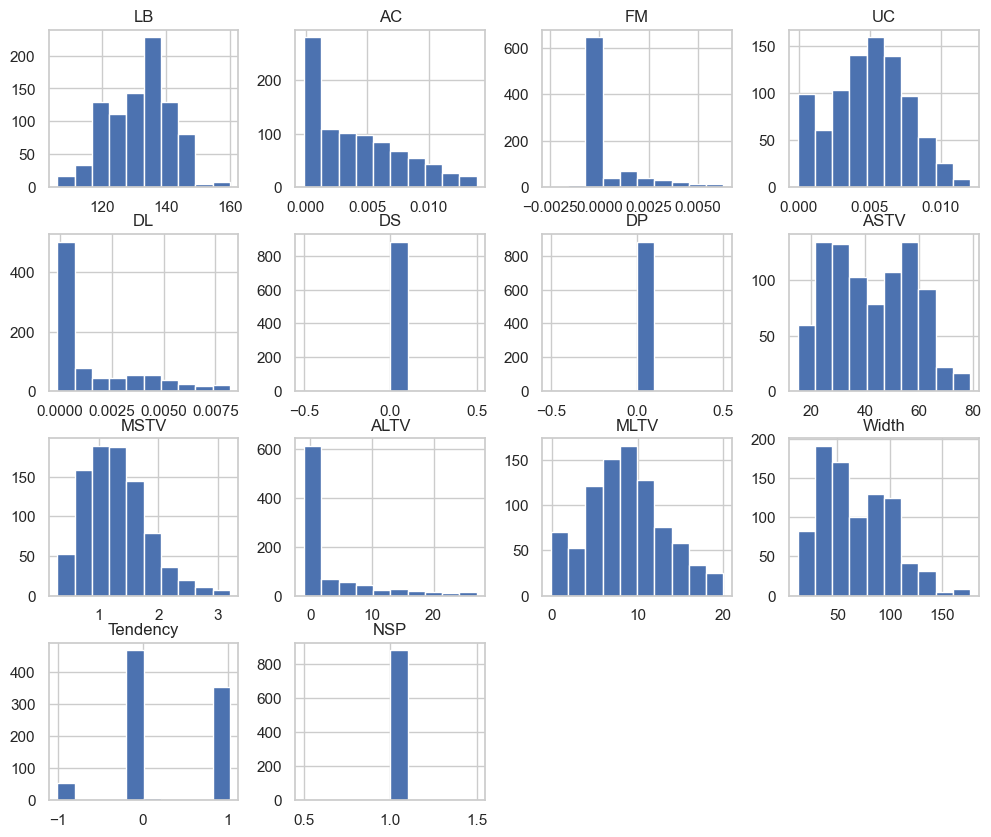

In [38]:
df.hist(figsize=(12,10))
plt.show()

5.2 Boxplot

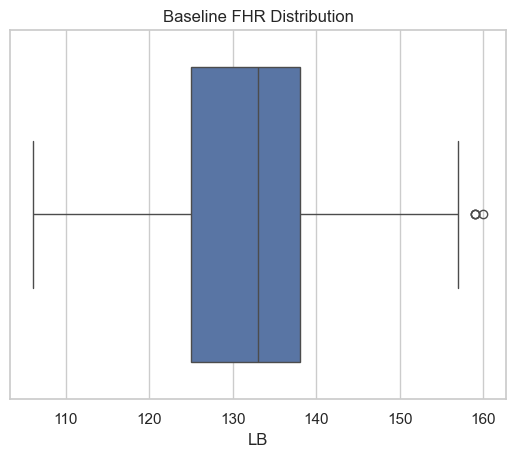

In [39]:
sns.boxplot(x=df['LB'])
plt.title("Baseline FHR Distribution")
plt.show()

5.3 Correlation Heatmap

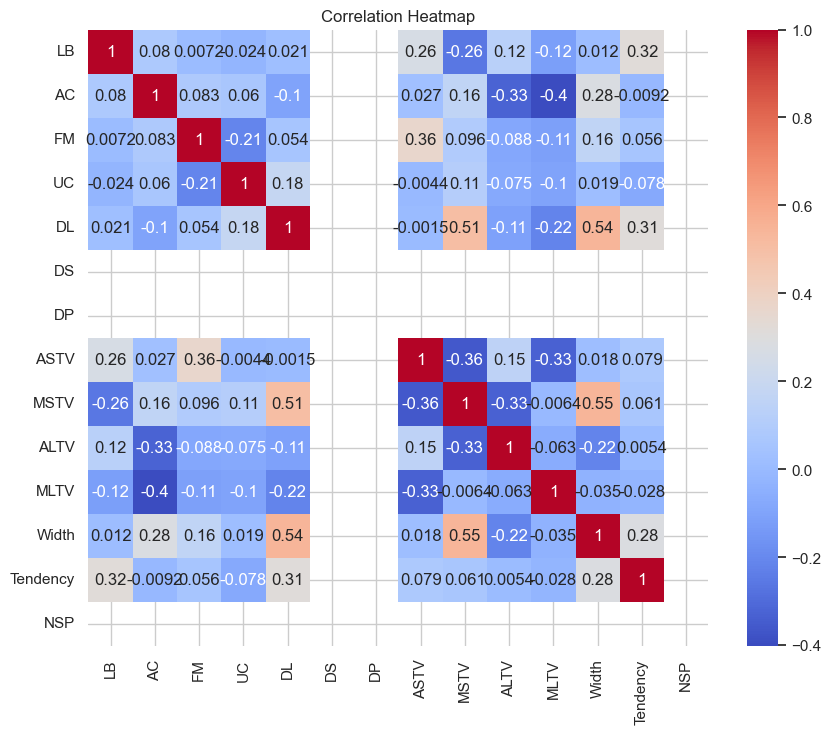

In [40]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

5.3 Scatter Plot

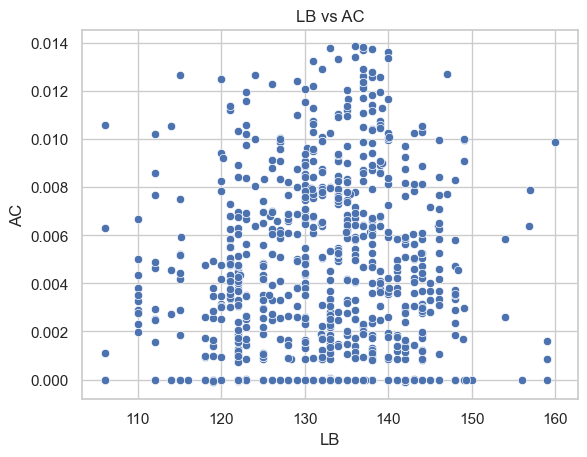

In [41]:
sns.scatterplot(x=df['LB'], y=df['AC'])
plt.title("LB vs AC")
plt.show()

5.4 Pair Plot

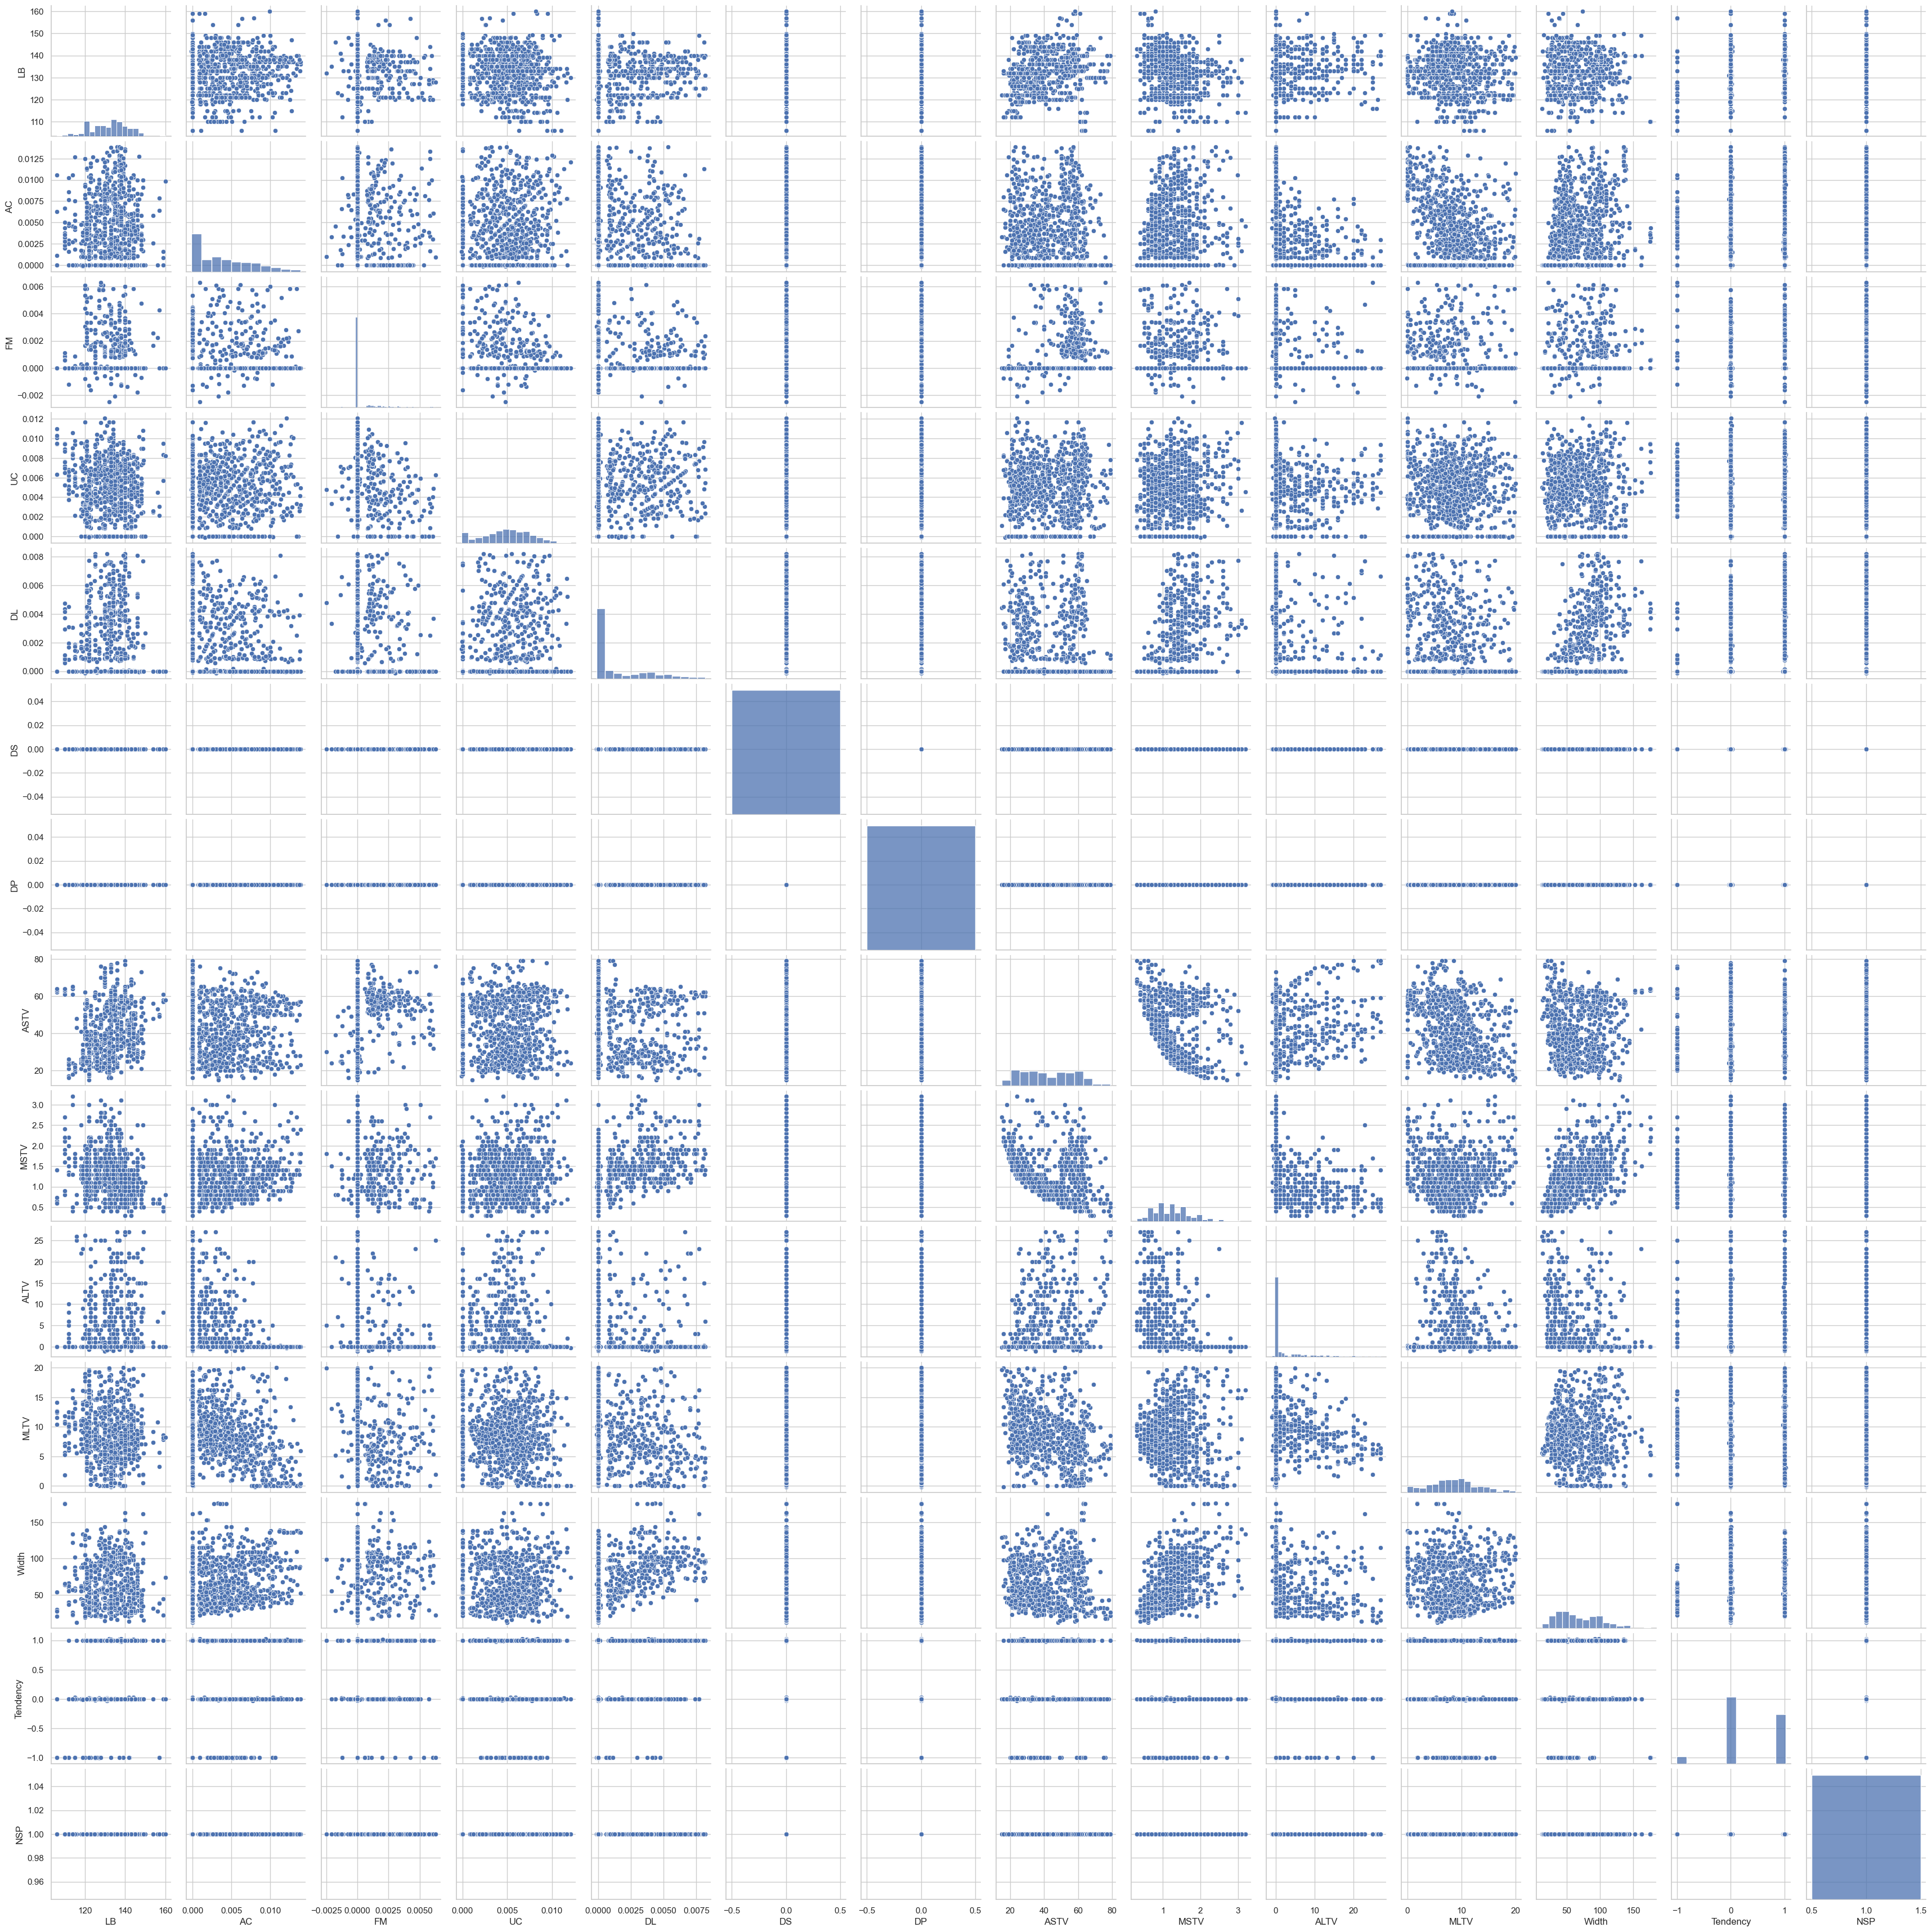

In [42]:
sns.pairplot(df)
plt.show()

 5.5Violin Plot 

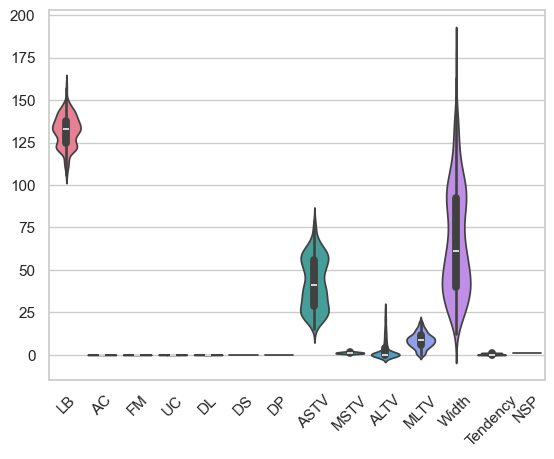

In [43]:
sns.violinplot(data=df)
plt.xticks(rotation=45)
plt.show()

6. Pattern Recognition & Insights

In [44]:
df.corr()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,0.079880,0.007221,-0.024043,0.020850,NaN,NaN,0.263728,-0.258983,0.124994,-0.118409,0.011791,0.315990,NaN
AC,0.079880,1.000000,0.082838,0.059763,-0.102355,NaN,NaN,0.027355,0.157814,-0.328318,-0.401056,0.282449,-0.009248,NaN
FM,0.007221,0.082838,1.000000,-0.210594,0.054073,NaN,NaN,0.362223,0.095904,-0.087823,-0.111782,0.162211,0.055835,NaN
UC,-0.024043,0.059763,-0.210594,1.000000,0.179120,NaN,NaN,-0.004439,0.108714,-0.074660,-0.103585,0.018992,-0.077725,NaN
DL,0.020850,-0.102355,0.054073,0.179120,1.000000,NaN,NaN,-0.001525,0.506833,-0.106325,-0.215279,0.540652,0.312391,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASTV,0.263728,0.027355,0.362223,-0.004439,-0.001525,NaN,NaN,1.000000,-0.357606,0.146468,-0.331045,0.018016,0.079154,NaN
MSTV,-0.258983,0.157814,0.095904,0.108714,0.506833,NaN,NaN,-0.357606,1.000000,-0.333940,-0.006386,0.545244,0.060625,NaN
ALTV,0.124994,-0.328318,-0.087823,-0.074660,-0.106325,NaN,NaN,0.146468,-0.333940,1.000000,-0.063275,-0.216387,0.005426,NaN


7. Conclusion

The dataset shows important relationships between fetal heart rate features.
Strong correlations between variables like LB and AC suggest indicators of fetal well-being.
Presence of outliers in variability features may indicate abnormal cases.
Visualization helped identify distributions and hidden patterns.

8. Report

Data was cleaned and preprocessed
Missing values handled using mean imputation
Statistical summary revealed variability in features
Visualizations showed distributions and correlations